<a href="https://colab.research.google.com/github/Fugant1/Health_EDA/blob/main/Entrega_1_AED_DisciplinaAMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***Disciplina de Aprendizado de Máquina Aplicado a Problemas (2026) - SME0860***
---
Alunos:
1. João Pedro Barbosa Madeira - 13683038
2. Julio Cesar A A Fuganti - 15638792
3. Victor Silva Botelho - 15645421

# ***Contextualização***

O presente trabalho utiliza dados do Sistema de Informação de Agravos de Notificação (**Sinan**), sendo o sistema informatizado do Ministério da Saúde utilizado no Brasil para registrar e processar dados de doenças e agravos de notificação compulsória.

Ele alimenta a vigilância epidemiológica com dados das unidades de saúde para identificar riscos, planejar intervenções e definir prioridades de saúde pública em nível municipal, estadual e federal.

O caso de estudo é a doença ***Malária***, uma doença infecciosa febril aguda, potencialmente grave, causada por parasitas do gênero *Plasmodium* e transmitida pela picada da fêmea infectada do mosquito *Anopheles* (mosquito-prego). Sendo comum em áreas tropicais, ela provoca sintomas como febre alta, calafrios, dores de cabeça e no corpo. Possui cura, mas exige tratamento rápido para evitar complicações fatais.


# *Imports*

In [ ]:
packages = [
    "pysus",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "dython",
    "scipy"
]

!pip install {' '.join(packages)}

In [1]:
from pysus import SINAN
from dython.nominal import associations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# *Aquisição de Dados*

In [63]:
sinan = SINAN().load()

In [64]:
files = sinan.get_files(dis_code=['MALA'])

In [65]:
parquet = sinan.download(files)

98243it [00:00, 35769184.71it/s]      


In [66]:
df = None
for p in parquet:
    p.to_dataframe()
    df = pd.concat([df, p.to_dataframe()])

In [67]:
display(df)

,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
0,2708006,2004054,2004-01-26,4,3,2004,042004,AL,008,2004-01-20,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2704302,0008133,2004-02-04,,,2004,052004,AL,,2004-01-02,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2704302,2720035,2004-01-06,4,9,2004,012004,AL,001,2003-12-30,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2704302,2720035,2004-01-07,1,9,2004,012004,AL,001,2004-01-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2704302,2720035,2004-01-02,4,9,2004,532003,AL,001,2004-01-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266,320530,11746,2024-12-16,4,<NA>,2024,202450,32,32002,2024-12-16,...,20241218,20241216,,,,,,,,
2267,320520,2445069,2024-12-27,4,<NA>,2024,202451,32,32002,2024-12-25,...,20250101,20241227,,,,,,,,
2268,320530,11800,2024-12-30,4,<NA>,2024,202452,32,32002,2024-12-29,...,20241231,20241230,,,,,,,,
2269,320530,11738,2024-11-17,3,<NA>,2024,202446,32,32002,2024-11-16,...,20250108,20241117,,,,,,,,


In [68]:
# Aglomerando os dados da malária num dataframe único

#df.to_csv('/content/malaria.csv', index=False)

## *Panorama Geral do Dataset*

In [69]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (68320, 102)
<class 'pandas.core.frame.DataFrame'>
Index: 68320 entries, 0 to 2270
Columns: 102 entries, ID_MUNICIP to NU_LOTE_H
dtypes: object(2), string(100)
memory usage: 53.7+ MB


,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
count,68320,68320,68320,68320,12026,68320,68320,68320,68320,68320,...,56294,56294,56294,56294,56294,56294,56294,56294,56294,56294
unique,2642,6183,7216,7,8,21,1203,45,300,7764,...,591,4826,1525,668,3989,1,847,569,1,1
top,330455,2506661,2018-08-09,4,3,2018,201832,32,,2018-08-09,...,,,,,,,,,,
freq,3676,2805,464,28141,2996,7939,1917,9654,10892,437,...,55101,216,53828,55126,34713,56294,53848,51751,56294,56294


In [70]:
lista_de_colunas = df.columns.tolist()
print(lista_de_colunas)

['ID_MUNICIP', 'ID_UNIDADE', 'DT_NOTIFIC', 'CS_RACA', 'CS_ESCOLAR', 'NU_ANO', 'SEM_NOT', 'SG_UF_NOT', 'ID_REGIONA', 'DT_SIN_PRI', 'SEM_PRI', 'NU_IDADE', 'CS_SEXO', 'ID_MN_RESI', 'SG_UF', 'ID_PAIS', 'ID_DG_NOT', 'ID_EV_NOT', 'ANT_DT_INV', 'OCUPACAO', 'TRANSFU', 'DTTRANSFU', 'UTRANSFU', 'UFTRANSFU', 'PTRANSFU', 'MTRANSFU', 'PUSUARIO', 'PMALARIA', 'AMALARIA', 'ASSINTOM', 'FEBRE', 'CALAFRIO', 'SUDORESE', 'CLI_OUTRO', 'CD_OUTRO', 'GESTANTE', 'HOSPITAL', 'DINTERNA', 'UFINTERNA', 'MINTERNA', 'DEXAME', 'PMM', 'PCRUZ', 'RESULT', 'CLOROQ', 'PRIMAQ', 'TETRAC', 'MEFLOQ', 'ARTESU', 'QUININO', 'ARTEM', 'CLIND', 'CLOROQI', 'QUININOI', 'ARTEI', 'ARTEMI', 'CLINDI', 'DOXOCI', 'SOUTROS', 'DTRATA', 'CON_CLASSI', 'CON_CONFIR', 'CON_INF_MU', 'CON_INF_UF', 'CON_INF_PA', 'CON_DOENCA', 'CON_EVOLUC', 'CON_DT_OBI', 'CON_DT_ENC', 'IN_VINCULA', 'NDUPLIC', 'TP_NOT', 'ID_AGRAVO', 'ANO_NASC', 'NU_IDADE_N', 'CS_GESTANT', 'CS_ESCOL_N', 'ID_RG_RESI', 'DT_INVEST', 'ID_OCUPA_N', 'CLASSI_FIN', 'AT_ATIVIDA', 'AT_LAMINA', 'A

### **1. Identificação da Notificação e Tempo**
Dados que situam o registro no tempo e no sistema administrativo.

Colunas: `NU_ANO, SEM_NOT, DT_NOTIFIC, TP_NOT, ID_AGRAVO, DT_DIGITA, ID_MUNICIP, ID_UNIDADE, ID_REGIONA, SG_UF_NOT`.

### **2. Perfil Demográfico do Paciente**
Informações sobre quem é a pessoa notificada.

Colunas: `NU_IDADE, NU_IDADE_N, ANO_NASC, CS_SEXO, CS_RACA, CS_ESCOLAR, CS_ESCOL_N, GESTANTE, CS_GESTANT, OCUPACAO, ID_OCUPA_N`.

### **3. Local de Residência e Fluxo Geográfico**
Onde o paciente mora e onde ele pode ter sido infectado.

Colunas: `ID_MN_RESI, ID_RG_RESI, SG_UF, ID_PAIS`.

### **4. Dados Clínicos e Sintomas**
O "quadro" do paciente no momento da suspeita.

Colunas: `DT_SIN_PRI, SEM_PRI, FEBRE, CALAFRIO, SUDORESE, ASSINTOM, CLI_OUTRO, CD_OUTRO, AT_SINTOMA`.

### **5. Histórico Epidemiológico e Investigação**
Fatores de risco e antecedentes de exposição.

Colunas: `ANT_DT_INV, DT_INVEST, TRANSFU, DTTRANSFU, UTRANSFU, UFTRANSFU, PTRANSFU, MTRANSFU, PMALARIA, AMALARIA, AT_ATIVIDA, AT_LAMINA`.

### **6. Diagnóstico Laboratorial**
Resultados de exames e a confirmação da doença.

Colunas: `DEXAME, PMM, PCRUZ, RESULT, CLASSI_FIN, CON_CLASSI, CON_CONFIR`.

### **7. Tratamento Ministrado**
Medicamentos e esquemas terapêuticos utilizados.

Colunas: `DTRATA, CLOROQ, PRIMAQ, TETRAC, MEFLOQ, ARTESU, QUININO, ARTEM, CLIND, CLOROQI, QUININOI, ARTEI, ARTEMI, CLINDI, DOXOCI, SOUTROS, TRA_ESQUEM, DSTRAESQUE`.

### **8. Internação e Local provável de Infecção (LPI)**
Dados sobre gravidade e origem da infecção.

Colunas: `HOSPITAL, DINTERNA, UFINTERNA, MINTERNA, TPAUTOCTO, COUFINF, COPAISINF, COMUNINF, LOC_INF`.

### **9. Conclusão e Desfecho do Caso**
Como o caso foi encerrado (cura, óbito, duplicidade).

Colunas: `CON_EVOLUC, CON_DT_OBI, CON_DT_ENC, DT_ENCERRA, CON_DOENCA, IN_VINCULA, NDUPLIC`.

### **10. Metadados e Controle do Sistema (Logs)**
Colunas técnicas para rastreamento de lotes e transferências de dados.

Colunas: `DT_TRANSUS, DT_TRANSDM, DT_TRANSSM, DT_TRANSRM, DT_TRANSRS, DT_TRANSSE, NU_LOTE_I, NU_LOTE_V, NU_LOTE_H, PUSUARIO`.

In [71]:
df.describe()

,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
count,68320,68320,68320,68320,12026,68320,68320,68320,68320,68320,...,56294,56294,56294,56294,56294,56294,56294,56294,56294,56294
unique,2642,6183,7216,7,8,21,1203,45,300,7764,...,591,4826,1525,668,3989,1,847,569,1,1
top,330455,2506661,2018-08-09,4,3,2018,201832,32,,2018-08-09,...,,,,,,,,,,
freq,3676,2805,464,28141,2996,7939,1917,9654,10892,437,...,55101,216,53828,55126,34713,56294,53848,51751,56294,56294


In [72]:
df.isna().sum()

ID_MUNICIP        0
ID_UNIDADE        0
DT_NOTIFIC        0
CS_RACA           0
CS_ESCOLAR    56294
              ...  
DT_TRANSRM    12026
DT_TRANSRS    12026
DT_TRANSSE    12026
NU_LOTE_V     12026
NU_LOTE_H     12026
Length: 102, dtype: int64

# *Pré-Processamento*

In [73]:
# 1. Mantendo as colunas importantes antes da remoção, mesmo se possuírem mais de 80% <NA>

old_df = df.copy()

cols_importantes = [
    "DT_NOTIFIC",
    "SG_UF_NOT",
    "ID_MUNICIP",
    "NU_IDADE_N",
    "CS_SEXO",
    "IDADE_LIMPA",
    "DIAS_SINTOMA_NOTIFIC",
    "CLASSI_FIN",
    "PMM",
    "ASSINTOM", "FEBRE",
    "CALAFRIO", "SUDORESE",
    "CON_EVOLUC",
    "CLOROQ", "PRIMAQ", 
    "TETRAC", "MEFLOQ", 
    "ARTESU", "QUININO"
]

# 2. calculando proporção de NaN
missing_ratio = df.isnull().mean()

# 3. definir threshold
threshold = 0.8

# 4. colunas para remover (exceto importantes)
cols_removidas = missing_ratio[
    (missing_ratio >= threshold) & (~missing_ratio.index.isin(cols_importantes))
].index

print(cols_removidas)

# 5. colunas mantidas
cols_mantidas = df.columns.difference(cols_removidas)

# 6. logs
print(f"Total de colunas antes: {df.shape[1]}")
print(f"Colunas removidas: {len(cols_removidas)}")
print(f"Colunas restantes: {len(cols_mantidas)}")

print("\nExemplo de colunas removidas:")
print(cols_removidas[:10])

# 7. aplicando remoção
df = df[cols_mantidas].copy()

Index(['CS_ESCOLAR', 'NU_IDADE', 'ID_DG_NOT', 'ID_EV_NOT', 'ANT_DT_INV',
       'OCUPACAO', 'TRANSFU', 'DTTRANSFU', 'UTRANSFU', 'UFTRANSFU', 'PTRANSFU',
       'MTRANSFU', 'PUSUARIO', 'PMALARIA', 'AMALARIA', 'CLI_OUTRO', 'CD_OUTRO',
       'GESTANTE', 'HOSPITAL', 'DINTERNA', 'UFINTERNA', 'MINTERNA', 'ARTEM',
       'CLIND', 'CLOROQI', 'QUININOI', 'ARTEI', 'ARTEMI', 'CLINDI', 'DOXOCI',
       'SOUTROS', 'CON_CLASSI', 'CON_CONFIR', 'CON_INF_MU', 'CON_INF_UF',
       'CON_INF_PA', 'CON_DOENCA', 'CON_DT_OBI', 'CON_DT_ENC', 'IN_VINCULA',
       'NDUPLIC'],
      dtype='object')
Total de colunas antes: 102
Colunas removidas: 41
Colunas restantes: 61

Exemplo de colunas removidas:
Index(['CS_ESCOLAR', 'NU_IDADE', 'ID_DG_NOT', 'ID_EV_NOT', 'ANT_DT_INV',
       'OCUPACAO', 'TRANSFU', 'DTTRANSFU', 'UTRANSFU', 'UFTRANSFU'],
      dtype='object')


In [74]:
# Tipos e quantidade das colunas restantes

print(df.dtypes.value_counts())

string[python]    59
object             2
Name: count, dtype: int64


In [75]:
# Separando em variáveis categóricas e numéricas

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in num_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].astype('object')
    df.loc[:, col] = df[col].fillna("Ignorado")

# Somando a quantidade de dados faltantes nesse novo df por coluna
df.isnull().sum().sort_values(ascending=False).head(10)

ANO_NASC      0
ARTESU        0
ASSINTOM      0
AT_ATIVIDA    0
AT_LAMINA     0
AT_SINTOMA    0
CALAFRIO      0
CLASSI_FIN    0
CLOROQ        0
COMUNINF      0
dtype: int64

In [76]:
# Colunas categóricas

print(cat_cols)

Index(['ANO_NASC', 'ARTESU', 'ASSINTOM', 'AT_ATIVIDA', 'AT_LAMINA',
       'AT_SINTOMA', 'CALAFRIO', 'CLASSI_FIN', 'CLOROQ', 'COMUNINF',
       'CON_EVOLUC', 'COPAISINF', 'COUFINF', 'CS_ESCOL_N', 'CS_GESTANT',
       'CS_RACA', 'CS_SEXO', 'DEXAME', 'DSTRAESQUE', 'DTRATA', 'DT_DIGITA',
       'DT_ENCERRA', 'DT_INVEST', 'DT_NOTIFIC', 'DT_SIN_PRI', 'DT_TRANSDM',
       'DT_TRANSRM', 'DT_TRANSRS', 'DT_TRANSSE', 'DT_TRANSSM', 'DT_TRANSUS',
       'FEBRE', 'ID_AGRAVO', 'ID_MN_RESI', 'ID_MUNICIP', 'ID_OCUPA_N',
       'ID_PAIS', 'ID_REGIONA', 'ID_RG_RESI', 'ID_UNIDADE', 'LOC_INF',
       'MEFLOQ', 'NU_ANO', 'NU_IDADE_N', 'NU_LOTE_H', 'NU_LOTE_I', 'NU_LOTE_V',
       'PCRUZ', 'PMM', 'PRIMAQ', 'QUININO', 'RESULT', 'SEM_NOT', 'SEM_PRI',
       'SG_UF', 'SG_UF_NOT', 'SUDORESE', 'TETRAC', 'TPAUTOCTO', 'TP_NOT',
       'TRA_ESQUEM'],
      dtype='object')


# *AED*

## *Análise Temporal*
O objetivo aqui é identificar sazonalidade e tendências de crescimento ou queda da doença.

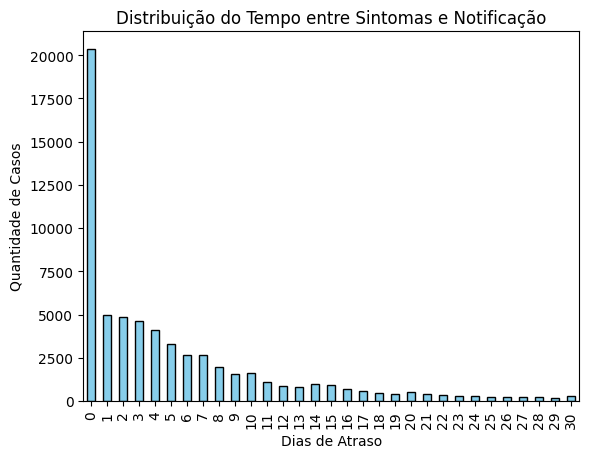

In [77]:
# Convertendo para datetime
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'])
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'])

# Calculando a diferença em dias
df['DIAS_ATRASO'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days

# remoção de valores negativos
df_filtrado = df[(df['DIAS_ATRASO'] >= 0) & (df['DIAS_ATRASO'] <= 30)]

# Contando a frequência de cada dia
contagem_atraso = df_filtrado['DIAS_ATRASO'].value_counts().sort_index()

# Plotando o gráfico de barras
contagem_atraso.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribuição do Tempo entre Sintomas e Notificação')
plt.xlabel('Dias de Atraso')
plt.ylabel('Quantidade de Casos')
plt.show()


## *Avaliando Sexo e Faixa Etária no Dataset*

/tmp/ipykernel_1635279/3618719643.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CS_SEXO', palette='Pastel1', ax=ax[0])


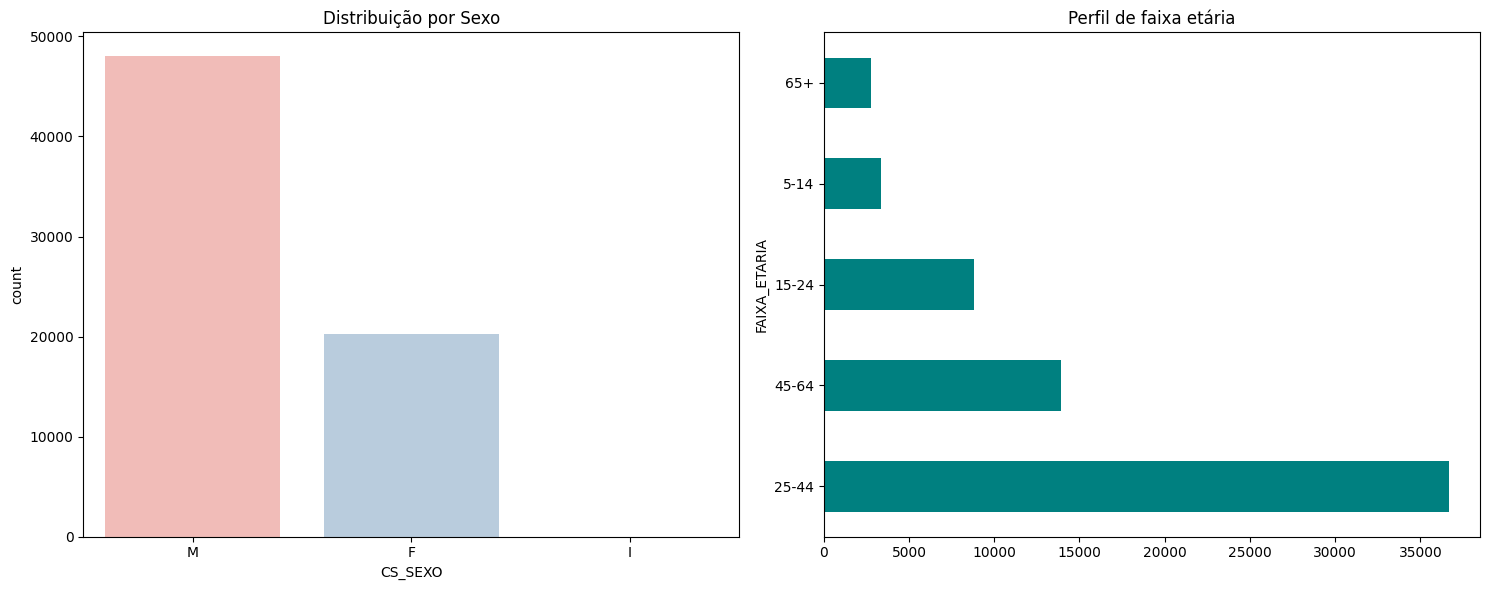

In [78]:
# 1. A Função à prova de balas
def consertar_idade_sinan_definitivo(valor):
    if pd.isna(valor):
        return np.nan

    valor_str = str(valor).strip().replace('.0', '')

    if len(valor_str) < 2:
        try: return float(valor_str)
        except: return np.nan

    prefixo = valor_str[0].upper()

    try:
        num = int(''.join(filter(str.isdigit, valor_str[1:])))
    except:
        return np.nan

    if prefixo in ['4', 'A']: return float(num)
    elif prefixo in ['3', 'M']: return num / 12
    elif prefixo in ['2', 'D']: return num / 365
    else:
        try: return float(valor_str)
        except: return np.nan

df['IDADE_LIMPA'] = df['NU_IDADE_N'].apply(consertar_idade_sinan_definitivo)

mediana_real = df['IDADE_LIMPA'].median()
df['IDADE_LIMPA'] = df['IDADE_LIMPA'].fillna(mediana_real)

# 2. Criando Faixas Etárias
bins = [0, 5, 14, 25, 45, 65, 120]
labels = ['0-4', '5-14', '15-24', '25-44', '45-64', '65+']
df['FAIXA_ETARIA'] = pd.cut(df['IDADE_LIMPA'], bins=bins, labels=labels)

# 3. Setup do Layout (1 linha, 2 colunas)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Distribuição por Sexo
sns.countplot(data=df, x='CS_SEXO', palette='Pastel1', ax=ax[0])
ax[0].set_title('Distribuição por Sexo')

# Gráfico B: Quantidade por Faixa Etária (Top 5)
df['FAIXA_ETARIA'].value_counts().head(5).plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Perfil de faixa etária')

plt.tight_layout()
plt.show()

## *Analisando Prevalência de Sintomas*

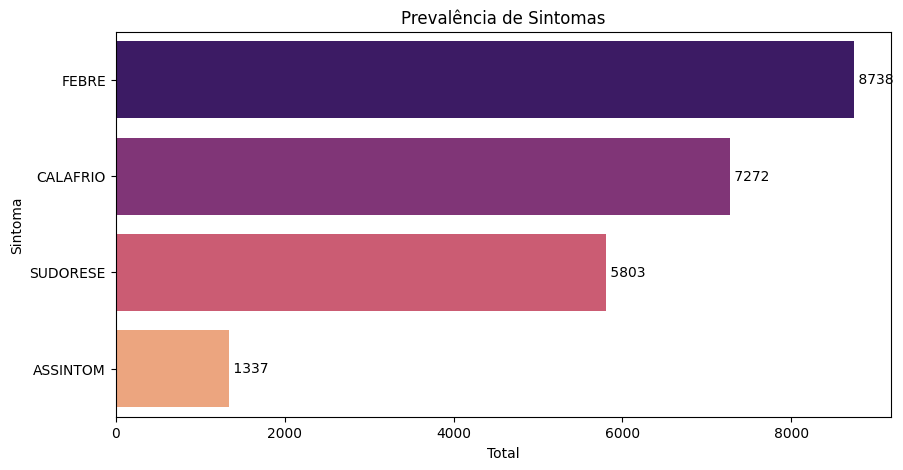

In [79]:
colunas_sintomas = ['FEBRE', 'CALAFRIO', 'SUDORESE', 'ASSINTOM']

# Criando a contagem de forma mais "agressiva"
contagem_sintomas = {}
for col in colunas_sintomas:
    if col in df.columns:
        # 1. Garante que é string e remove espaços (ex: ' 1 ' vira '1')
        # 2. Conta quantos são '1' ou 1
        serie_limpa = df[col].astype(str).str.strip()
        contagem_sintomas[col] = (serie_limpa == '1').sum()
    else:
        print(f"Aviso: Coluna {col} não encontrada no CSV!")

# Criando o DataFrame para o gráfico
df_sintomas = pd.DataFrame(list(contagem_sintomas.items()), columns=['Sintoma', 'Total'])
df_sintomas = df_sintomas.sort_values(by='Total', ascending=False)

# Plot (Removendo o aviso de 'palette' usando o parâmetro 'hue')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sintomas, x='Total', y='Sintoma', hue='Sintoma', palette='magma', legend=False)

# Adicionando os números nas barras
for i, valor in enumerate(df_sintomas['Total']):
    plt.text(valor, i, f' {int(valor)}', va='center')

plt.title('Prevalência de Sintomas')
plt.show()

## *Analisando os medicamentos utilizados de acordo com o desfecho do paciente*

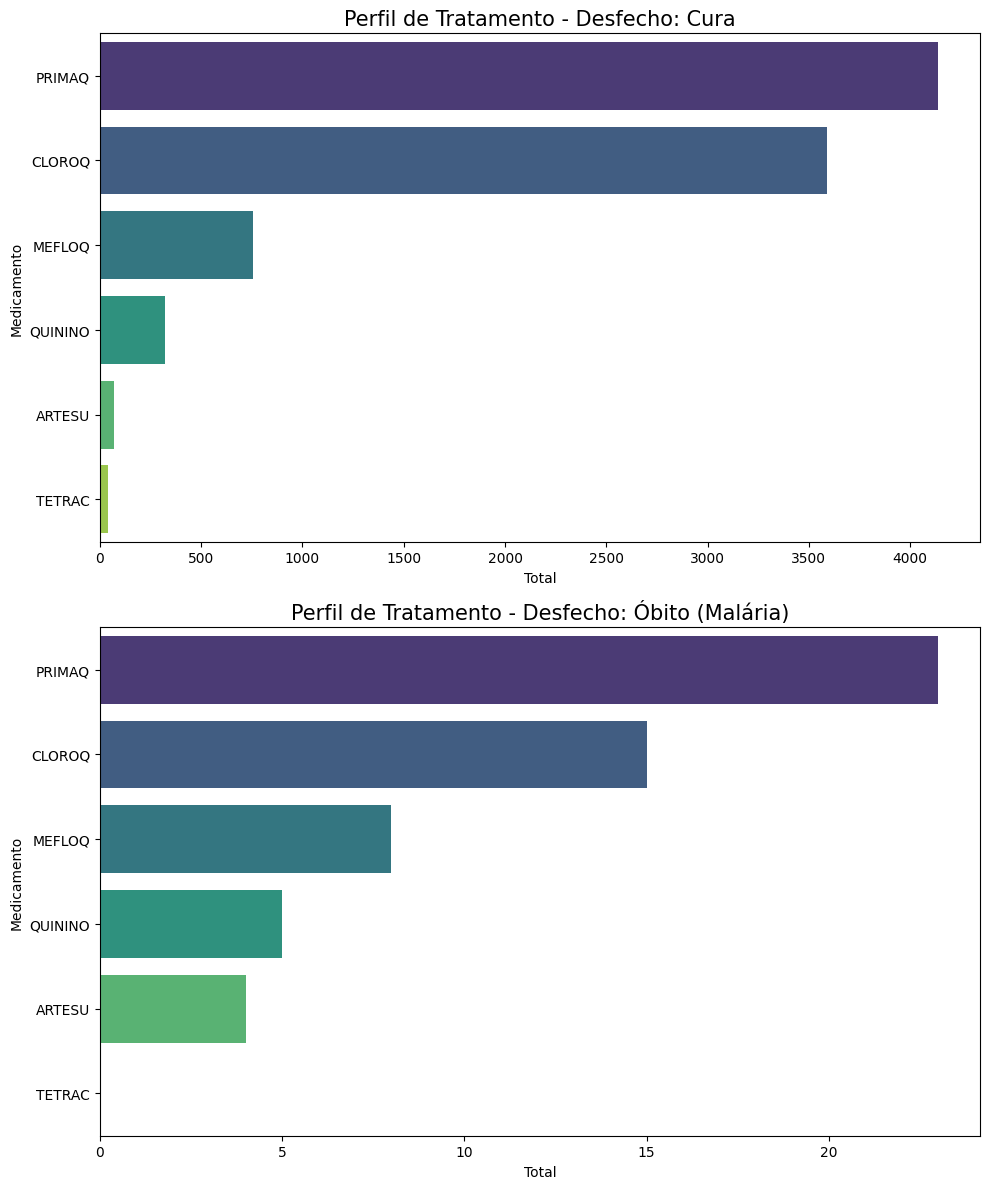

In [80]:
# 1. Lista de tratamentos
colunas_tratamento = ['CLOROQ', 'PRIMAQ', 'TETRAC', 'MEFLOQ', 'ARTESU', 'QUININO']

# 2. Diagnóstico: Vamos ver o que realmente tem na coluna de desfecho
coluna_alvo = 'CON_EVOLUC'

# Convertemos para string para evitar problemas de tipo (1 vs 1.0 vs '1')
df[coluna_alvo] = df[coluna_alvo].astype(str).str.replace('.0', '', regex=False).str.strip()

mapa_desfechos = {
    '1': 'Cura',
    '2': 'Óbito (Malária)',
    '3': 'Óbito (Outros)',
    '4': 'Abandono'
}
df['DESFECHO_NOME'] = df[coluna_alvo].map(mapa_desfechos)

# Filtrar apenas desfechos que conseguimos mapear e que não são "nan"
df_validos = df[df['DESFECHO_NOME'].notna() & (df['DESFECHO_NOME'] != 'nan')]
desfechos_unicos = df_validos['DESFECHO_NOME'].unique()

# Verificação de segurança
if len(desfechos_unicos) == 0:
    print(f"ERRO: Nenhum desfecho encontrado na coluna {coluna_alvo}!")
    print("Valores únicos encontrados na coluna:", df[coluna_alvo].unique())
else:
    # 3. Criar a figura
    fig, axes = plt.subplots(nrows=len(desfechos_unicos), ncols=1,
                             figsize=(10, 6 * len(desfechos_unicos)))

    # Se houver apenas 1 gráfico, o axes não vem como lista
    if len(desfechos_unicos) == 1: axes = [axes]

    for i, desfecho in enumerate(desfechos_unicos):
        df_temp = df_validos[df_validos['DESFECHO_NOME'] == desfecho]

        contagem = {}
        for col in colunas_tratamento:
            if col in df.columns:
                # Conta tanto o número 1 quanto a string '1'
                contagem[col] = (df_temp[col].astype(str).str.strip() == '1').sum()

        df_plot = pd.DataFrame(contagem.items(), columns=['Medicamento', 'Total']).sort_values('Total', ascending=False)

        sns.barplot(data=df_plot, x='Total', y='Medicamento', ax=axes[i], palette='viridis', hue='Medicamento', legend=False)
        axes[i].set_title(f'Perfil de Tratamento - Desfecho: {desfecho}', fontsize=15)

    plt.tight_layout()
    plt.show()

## *Observações de alguns medicamentos mencionados*

**Primaquina:** é um medicamento antimalárico fundamental para a cura radical de *Plasmodium vivax* e *P. ovale*, atuando nas formas latentes no fígado (hipnozoítos) e prevenindo recaídas. Geralmente usada com a cloroquina, é indicada para o tratamento e profilaxia terminal da malária, sendo contraindicada na gravidez.

**Cloroquina:** é um medicamento utilizado para tratar a Malária e doenças autoimunes como **lúpus** e **artrite reumatoide**.

**Mefloquina:** Comumente comercializada como **Lariam** ou produzida como genérico, é um medicamento antimalárico oral, derivado do quinino, usado para a prevenção e tratamento da malária, particularmente o *Plasmodium falciparum*.

## *Análise de Correlação entre variáveis **numéricas** e **temporais***

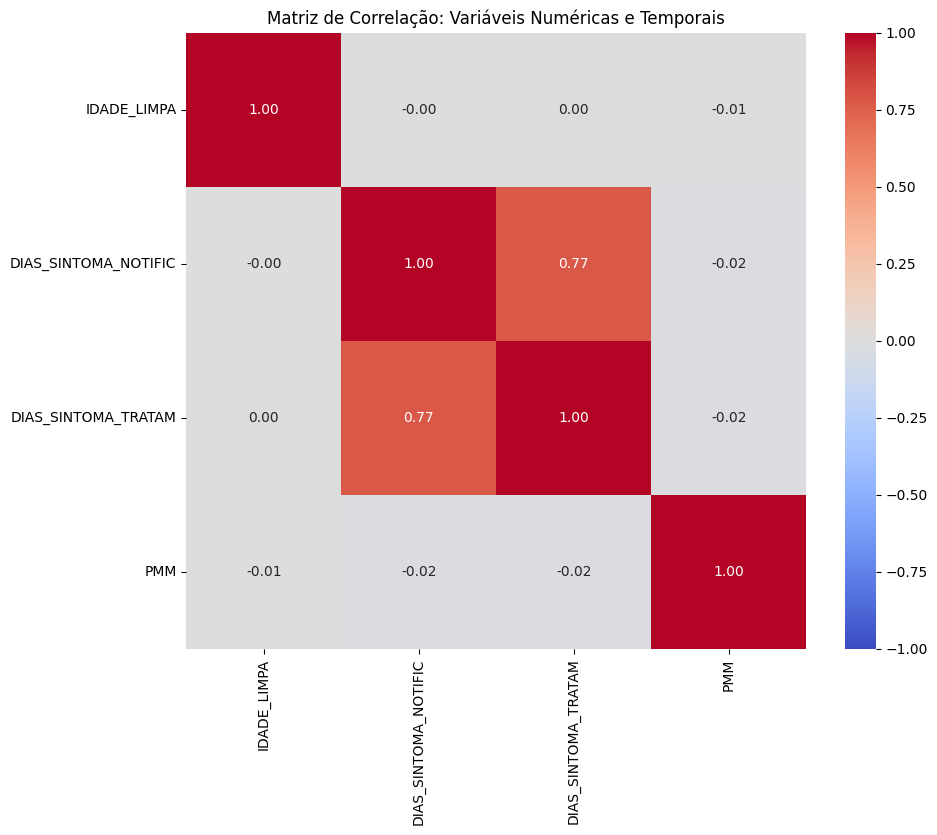

In [81]:
# 1. Convertendo datas com 'coerce' para ignorar anos impossíveis (por ex, o ano 1007)

# O format='mixed' ajuda o pandas a entender diferentes formatos de data se houver
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')
df['DTRATA'] = pd.to_datetime(df['DTRATA'], errors='coerce')

# 2. Calculando os atrasos em dias
df['DIAS_SINTOMA_NOTIFIC'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days
df['DIAS_SINTOMA_TRATAM'] = (df['DTRATA'] - df['DT_SIN_PRI']).dt.days

# 3. Limpeza de Outliers (Importante para a correlação não ser destruída por erros)
# Removemos dias negativos ou atrasos absurdos (ex: > 365 dias)
df_corr = df[
    (df['DIAS_SINTOMA_NOTIFIC'] >= 0) & (df['DIAS_SINTOMA_NOTIFIC'] <= 365) &
    (df['DIAS_SINTOMA_TRATAM'] >= 0) & (df['DIAS_SINTOMA_TRATAM'] <= 365)
].copy()

# 4. Selecionando colunas numéricas
colunas_corr = ['IDADE_LIMPA', 'DIAS_SINTOMA_NOTIFIC', 'DIAS_SINTOMA_TRATAM']

# Adiciona PMM se ela for numérica
if 'PMM' in df.columns:
    df_corr['PMM'] = pd.to_numeric(df_corr['PMM'], errors='coerce')
    colunas_corr.append('PMM')

# 5. Gerando a Matriz
plt.figure(figsize=(10, 8))
matriz = df_corr[colunas_corr].corr()

sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação: Variáveis Numéricas e Temporais')
plt.show()

## *Matriz de Asssociação da Malária*

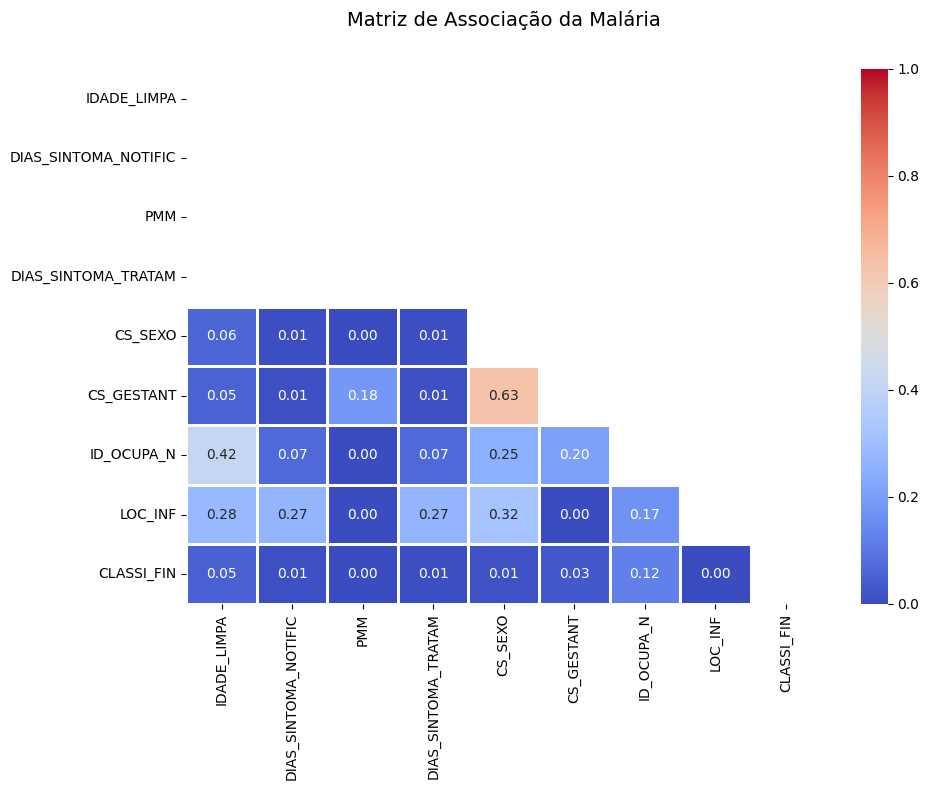

In [84]:
colunas_analise = ['IDADE_LIMPA', 'DIAS_SINTOMA_NOTIFIC', 'PMM', 'DIAS_SINTOMA_TRATAM', 'CS_SEXO', 'CS_GESTANT', 'ID_OCUPA_N', 'LOC_INF', 'CLASSI_FIN']

df_reduzido = df[colunas_analise].copy()

df_clinico = df_reduzido[
    (df_reduzido['CLASSI_FIN'] != 'Ignorado') &
    (df_reduzido['CS_SEXO'] != 'Ignorado') &
    (df_reduzido['ID_OCUPA_N'] != 'Ignorado') &
    (df_reduzido['LOC_INF'] != 'Ignorado')
].copy()

resultado = associations(df_clinico,
                         nom_nom_assoc='cramer',
                         nom_num_assoc='correlation_ratio',
                         nan_strategy='drop_samples',
                         compute_only=True)

matriz_corr = resultado['corr']

cols_num = ['IDADE_LIMPA', 'DIAS_SINTOMA_NOTIFIC', 'PMM', 'DIAS_SINTOMA_TRATAM']

for col1 in cols_num:
    for col2 in cols_num:
        if col1 != col2:
            matriz_corr.loc[col1, col2] = np.nan

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr,
            annot=True,
            mask=mask,
            cmap='coolwarm',
            fmt=".2f",
            vmin=0, vmax=1,
            linewidths=1,
            linecolor='white')

plt.title("Matriz de Associação da Malária\n", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## *Analisando a quantidade de pacientes nos novos dataframes "reduzido" e "clínico"*

In [83]:
print(f"Pacientes no df_reduzido (Original): {len(df_reduzido)}")
print(f"Pacientes no df_clinico (Filtrado): {len(df_clinico)}")

Pacientes no df_reduzido (Original): 68320
Pacientes no df_clinico (Filtrado): 56294
